# EEG-Based Major Depressive Disorder (MDD) Classification
**Pipeline:** Data Loading → Preprocessing → Feature Extraction → Feature Selection → Classification → Evaluation

Implements the full methodology for both **19-channel** and **4-channel** configurations:
- Spectral band power (delta, theta, alpha, beta) via Welch periodogram
- Alpha interhemispheric asymmetry across region pairs
- AUC-based feature selection
- LR / SVM / Naïve Bayes classifiers
- Monte Carlo 10-fold CV (100 repetitions)

## Cell 1 — Install & Import Libraries

In [1]:
# ── Install required packages (run once) ──────────────────────────────────────
# !pip install mne numpy scipy scikit-learn pandas matplotlib seaborn tqdm

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import mne
from scipy.signal import welch
from scipy.stats import zscore

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## Cell 2 — Global Configuration

In [2]:
# ── Directory ─────────────────────────────────────────────────────────────────
EEG_DIR = Path("EEG data")          # Folder containing all .edf files

# ── Channel sets ──────────────────────────────────────────────────────────────
CHANNELS_19 = [
    'EEG Fp1-LE', 'EEG F3-LE',  'EEG C3-LE',  'EEG P3-LE',
    'EEG O1-LE',  'EEG F7-LE',  'EEG T3-LE',  'EEG T5-LE',
    'EEG Fz-LE',  'EEG Fp2-LE', 'EEG F4-LE',  'EEG C4-LE',
    'EEG P4-LE',  'EEG O2-LE',  'EEG F8-LE',  'EEG T4-LE',
    'EEG T6-LE',  'EEG Cz-LE',  'EEG Pz-LE'
]

CHANNELS_4 = [
    'EEG Fp1-LE', 'EEG Fp2-LE',
    'EEG F3-LE',  'EEG F4-LE'
]

# ── Interhemispheric asymmetry channel pairs ───────────────────────────────────
# Format: (left_channel, right_channel, region_label)
ASYM_PAIRS_19 = [
    ('EEG Fp1-LE', 'EEG Fp2-LE', 'Frontal_Fp'),
    ('EEG F3-LE',  'EEG F4-LE',  'Frontal_F'),
    ('EEG F7-LE',  'EEG F8-LE',  'Frontal_F7F8'),
    ('EEG T3-LE',  'EEG T4-LE',  'Temporal_T3T4'),
    ('EEG T5-LE',  'EEG T6-LE',  'Temporal_T5T6'),
    ('EEG C3-LE',  'EEG C4-LE',  'Central_C3C4'),
    ('EEG P3-LE',  'EEG P4-LE',  'Parietal_P3P4'),
    ('EEG O1-LE',  'EEG O2-LE',  'Occipital_O1O2'),
]

ASYM_PAIRS_4 = [
    ('EEG Fp1-LE', 'EEG Fp2-LE', 'Frontal_Fp'),
    ('EEG F3-LE',  'EEG F4-LE',  'Frontal_F'),
]

# ── EEG frequency bands ───────────────────────────────────────────────────────
BANDS = {
    'delta': (0.5, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta':  (13.0, 30.0)
}

# ── Signal parameters ─────────────────────────────────────────────────────────
CLEAN_DURATION_SEC = 120        # 120 s of clean epochs per subject
WELCH_NPERSEG      = 256        # Welch window length (samples)

# ── Cross-validation ──────────────────────────────────────────────────────────
N_FOLDS   = 10
N_REPEATS = 100
SEED      = 42

# ── Feature subset sizes to evaluate ─────────────────────────────────────────
FEATURE_SUBSETS = [5, 10, 15, 19]

print("✅ Configuration set.")
print(f"   EEG folder : {EEG_DIR.resolve()}")
print(f"   19-ch count: {len(CHANNELS_19)} | 4-ch count: {len(CHANNELS_4)}")
print(f"   Bands      : {list(BANDS.keys())}")
print(f"   CV         : {N_REPEATS}x {N_FOLDS}-fold Monte Carlo")

✅ Configuration set.
   EEG folder : G:\For Job\EEG project\EEG data
   19-ch count: 19 | 4-ch count: 4
   Bands      : ['delta', 'theta', 'alpha', 'beta']
   CV         : 100x 10-fold Monte Carlo


## Cell 3 — Data Loading

In [3]:
def load_edf_file(filepath: Path, channel_set: list) -> np.ndarray | None:
    """
    Load an EDF file and return a 2-D array [n_channels, n_samples].
    Picks only the channels in `channel_set`.
    Returns None if any channel is missing.
    """
    try:
        raw = mne.io.read_raw_edf(str(filepath), preload=True, verbose=False)
        available = raw.ch_names
        missing   = [ch for ch in channel_set if ch not in available]
        if missing:
            print(f"  ⚠  {filepath.name} — missing channels: {missing}")
            return None, None
        raw.pick_channels(channel_set)
        # Preserve channel order
        raw.reorder_channels(channel_set)
        data = raw.get_data()          # [n_ch, n_samples]
        sfreq = raw.info['sfreq']
        return data, sfreq
    except Exception as e:
        print(f"  ✗ Failed to load {filepath.name}: {e}")
        return None, None


def discover_files(eeg_dir: Path):
    """Return sorted lists of (path, label) for MDD and HC files."""
    mdd_files = sorted(eeg_dir.glob("MDD*.edf"))
    hc_files  = sorted(eeg_dir.glob("H*.edf"))
    print(f"  Found {len(mdd_files)} MDD files and {len(hc_files)} HC files")
    return mdd_files, hc_files


def load_dataset(eeg_dir: Path, channel_set: list):
    """
    Load all EDF files and return:
        raw_data : list of [n_ch, n_samples] arrays
        labels   : list of int  (1 = MDD, 0 = HC)
        sfreqs   : list of sampling frequencies
        filenames: list of file names (for reference)
    """
    mdd_files, hc_files = discover_files(eeg_dir)
    raw_data, labels, sfreqs, filenames = [], [], [], []

    for group_files, label in [(mdd_files, 1), (hc_files, 0)]:
        tag = "MDD" if label == 1 else "HC"
        print(f"\n  Loading {tag} files...")
        for fp in tqdm(group_files, desc=f"  {tag}"):
            data, sfreq = load_edf_file(fp, channel_set)
            if data is not None:
                raw_data.append(data)
                labels.append(label)
                sfreqs.append(sfreq)
                filenames.append(fp.name)

    print(f"\n  ✅ Loaded {labels.count(1)} MDD + {labels.count(0)} HC subjects.")
    return raw_data, np.array(labels), sfreqs, filenames


print("✅ Data loading functions defined.")

✅ Data loading functions defined.


## Cell 4 — Preprocessing

In [4]:
def preprocess_signal(
    data: np.ndarray,
    sfreq: float,
    l_freq: float = 0.5,
    h_freq: float = 40.0,
    notch_freq: float = 50.0,
    clean_duration_sec: int = CLEAN_DURATION_SEC
) -> np.ndarray | None:
    """
    Preprocessing pipeline (MNE-based; mirrors BESA-style artifact removal):
      1. Bandpass filter  : 0.5–40 Hz  (removes baseline drift & HF noise)
      2. Notch filter     : 50 Hz      (power-line removal)
      3. Amplitude-based artifact rejection (|signal| > threshold μV)
      4. Select first `clean_duration_sec` seconds of accepted data

    Returns clipped array [n_ch, n_clean_samples] or None if insufficient data.

    NOTE: For a production pipeline, replace step 3 with full ICA/BESA artifact
          removal (eye blinks, muscle, cardiac) as used in the original study.
    """
    n_ch, n_samples = data.shape
    n_clean_needed  = int(clean_duration_sec * sfreq)

    # ── 1. Bandpass filter ────────────────────────────────────────────────────
    from mne.filter import filter_data
    data = filter_data(
        data, sfreq=sfreq,
        l_freq=l_freq, h_freq=h_freq,
        method='fir', verbose=False
    )

    # ── 2. Notch filter ───────────────────────────────────────────────────────
    data = filter_data(
        data, sfreq=sfreq,
        l_freq=notch_freq - 1, h_freq=notch_freq + 1,
        method='fir', fir_window='blackman',
        l_trans_bandwidth=0.5, h_trans_bandwidth=0.5,
        verbose=False
    )
    # Simple inversion trick — subtract the narrow band to notch
    data_notched = filter_data(
        data, sfreq=sfreq,
        l_freq=None, h_freq=notch_freq - 1,
        method='fir', verbose=False
    )
    data = data_notched

    # ── 3. Amplitude-based artifact rejection (epoch-wise, 1-s epochs) ────────
    AMPLITUDE_THRESHOLD_UV = 100e-6      # 100 µV peak-to-peak rejection
    epoch_len = int(sfreq)               # 1-second epochs
    n_epochs  = n_samples // epoch_len

    clean_epochs = []
    for i in range(n_epochs):
        seg = data[:, i * epoch_len : (i + 1) * epoch_len]
        if np.max(np.abs(seg)) < AMPLITUDE_THRESHOLD_UV:
            clean_epochs.append(seg)

    if len(clean_epochs) == 0:
        return None

    clean_data = np.concatenate(clean_epochs, axis=1)   # [n_ch, n_clean]

    # ── 4. Trim to required clean duration ────────────────────────────────────
    if clean_data.shape[1] < n_clean_needed:
        print(f"    ⚠  Only {clean_data.shape[1]/sfreq:.1f}s clean "
              f"(need {clean_duration_sec}s) — subject excluded.")
        return None

    return clean_data[:, :n_clean_needed]


def preprocess_all(raw_data, sfreqs, labels, filenames):
    """Apply preprocessing to all subjects; drop those with insufficient data."""
    processed, new_labels, new_names = [], [], []
    print("  Preprocessing subjects...")
    for data, sfreq, lbl, name in tqdm(
            zip(raw_data, sfreqs, labels, filenames), total=len(labels)):
        cleaned = preprocess_signal(data, sfreq)
        if cleaned is not None:
            processed.append(cleaned)
            new_labels.append(lbl)
            new_names.append(name)
    print(f"  ✅ {len(processed)}/{len(labels)} subjects passed preprocessing.")
    return processed, np.array(new_labels), new_names


print("✅ Preprocessing functions defined.")

✅ Preprocessing functions defined.


## Cell 5 — Feature Extraction

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  5A. Spectral Band Power (Welch periodogram)
# ─────────────────────────────────────────────────────────────────────────────

def compute_band_power(
    signal: np.ndarray,
    sfreq: float,
    band: tuple,
    nperseg: int = WELCH_NPERSEG
) -> float:
    """
    Compute absolute band power for a 1-D signal using Welch's method.
    Power = integral of PSD over the band (trapezoidal rule).
    """
    freqs, psd = welch(signal, fs=sfreq, nperseg=nperseg)
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    return np.trapz(psd[idx], freqs[idx])


def extract_spectral_features(
    data: np.ndarray,
    sfreq: float,
    channel_names: list,
    bands: dict = BANDS
) -> tuple:
    """
    Extract spectral power for every channel × every band.
    Returns:
        features   : 1-D array [n_channels * n_bands]
        feat_names : matching list of strings
    """
    features, feat_names = [], []
    for ch_idx, ch_name in enumerate(channel_names):
        for band_name, band_range in bands.items():
            power = compute_band_power(data[ch_idx], sfreq, band_range)
            features.append(power)
            # Clean channel label for readability
            ch_label = ch_name.replace('EEG ', '').replace('-LE', '')
            feat_names.append(f"{ch_label}_{band_name}")
    return np.array(features), feat_names


# ─────────────────────────────────────────────────────────────────────────────
#  5B. Alpha Interhemispheric Asymmetry
# ─────────────────────────────────────────────────────────────────────────────

def compute_alpha_asymmetry(
    data: np.ndarray,
    sfreq: float,
    channel_names: list,
    asym_pairs: list,
    alpha_band: tuple = (8.0, 13.0)
) -> tuple:
    """
    Compute log-transformed interhemispheric alpha asymmetry.
    Asymmetry(pair) = ln(P_right) − ln(P_left)

    Positive values → greater right-hemisphere alpha (i.e. less right activation)
    Standard frontal alpha asymmetry biomarker for depression.

    Returns:
        features   : 1-D array [n_pairs]
        feat_names : matching list of strings
    """
    ch_index = {ch: i for i, ch in enumerate(channel_names)}
    features, feat_names = [], []

    for left_ch, right_ch, label in asym_pairs:
        if left_ch not in ch_index or right_ch not in ch_index:
            continue  # skip pairs not available in this channel set
        p_left  = compute_band_power(data[ch_index[left_ch]],  sfreq, alpha_band)
        p_right = compute_band_power(data[ch_index[right_ch]], sfreq, alpha_band)
        # Guard against log(0)
        p_left  = max(p_left,  1e-12)
        p_right = max(p_right, 1e-12)
        asym = np.log(p_right) - np.log(p_left)
        features.append(asym)
        feat_names.append(f"Asym_{label}_alpha")

    return np.array(features), feat_names


# ─────────────────────────────────────────────────────────────────────────────
#  5C. Combined feature extraction (spectral + asymmetry)
# ─────────────────────────────────────────────────────────────────────────────

def extract_all_features(
    processed_data: list,
    sfreqs: list,
    channel_names: list,
    asym_pairs: list
) -> tuple:
    """
    Build the full feature matrix X [n_subjects, n_features].
    Both spectral-power features and alpha-asymmetry features are extracted.
    Returns X (raw, un-normalised), spectral_names, asym_names.
    """
    X_spectral, X_asymmetry = [], []
    spec_names = asym_names = None

    for data, sfreq in tqdm(
            zip(processed_data, sfreqs),
            total=len(processed_data), desc="  Extracting features"):

        sf, sn = extract_spectral_features(data, sfreq, channel_names)
        af, an = compute_alpha_asymmetry(data, sfreq, channel_names, asym_pairs)

        X_spectral.append(sf)
        X_asymmetry.append(af)

        if spec_names is None:
            spec_names = sn
            asym_names = an

    X_spec = np.array(X_spectral)    # [n_subj, n_ch*n_bands]
    X_asym = np.array(X_asymmetry)   # [n_subj, n_pairs]

    print(f"  ✅ Spectral features : {X_spec.shape}  ({len(spec_names)} features)")
    print(f"  ✅ Asymmetry features: {X_asym.shape}  ({len(asym_names)} features)")

    return X_spec, X_asym, spec_names, asym_names


print("✅ Feature extraction functions defined.")

✅ Feature extraction functions defined.


## Cell 6 — Feature Matrix Construction & Z-Score Normalisation

In [6]:
def build_feature_matrix(
    X_spec: np.ndarray,
    X_asym: np.ndarray,
    spec_names: list,
    asym_names: list
) -> tuple:
    """
    Concatenate spectral and asymmetry feature matrices column-wise,
    then apply z-score normalisation across subjects (per feature).

    Also returns:
      - X_spec_z  : normalised spectral-only matrix
      - X_asym_z  : normalised asymmetry-only matrix
      - X_comb_z  : normalised combined matrix
      - all_names : combined feature name list
    """
    # Concatenate
    X_combined = np.concatenate([X_spec, X_asym], axis=1)
    all_names  = spec_names + asym_names

    # Z-score normalise (each feature → mean 0, std 1 across subjects)
    X_spec_z  = zscore(X_spec,     axis=0)
    X_asym_z  = zscore(X_asym,     axis=0)
    X_comb_z  = zscore(X_combined, axis=0)

    # Replace NaN (constant features → std=0) with 0
    X_spec_z  = np.nan_to_num(X_spec_z)
    X_asym_z  = np.nan_to_num(X_asym_z)
    X_comb_z  = np.nan_to_num(X_comb_z)

    print(f"  Combined feature matrix : {X_comb_z.shape}")
    print(f"  Spectral   (z-scored)   : {X_spec_z.shape}")
    print(f"  Asymmetry  (z-scored)   : {X_asym_z.shape}")

    return X_spec_z, X_asym_z, X_comb_z, all_names


print("✅ Feature matrix builder defined.")

✅ Feature matrix builder defined.


## Cell 7 — AUC-Based Feature Selection

In [7]:
from sklearn.metrics import roc_auc_score


def rank_features_by_auc(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list
) -> pd.DataFrame:
    """
    Rank each feature by its univariate AUC score (ability to discriminate
    MDD from HC on its own). AUC is symmetrised so values < 0.5 are flipped.
    Returns a DataFrame sorted by AUC descending.
    """
    aucs = []
    for i in range(X.shape[1]):
        auc = roc_auc_score(y, X[:, i])
        auc = max(auc, 1 - auc)   # symmetrise: treat 0.3 same as 0.7
        aucs.append(auc)

    df = pd.DataFrame({
        'feature': feature_names,
        'AUC':     aucs
    }).sort_values('AUC', ascending=False).reset_index(drop=True)
    df['rank'] = df.index + 1
    return df


def select_top_features(
    X: np.ndarray,
    ranked_df: pd.DataFrame,
    n_top: int
) -> tuple:
    """
    Return the sub-matrix and names for the top-n ranked features.
    """
    top_names = ranked_df['feature'].head(n_top).tolist()
    # Map feature names back to column indices in X
    all_names  = ranked_df['feature'].tolist()
    top_idx    = ranked_df.head(n_top).index.tolist()
    return X[:, top_idx], top_names


def plot_feature_ranking(ranked_df: pd.DataFrame, top_n: int = 20, title: str = ""):
    """Horizontal bar chart of top-n features by AUC."""
    top = ranked_df.head(top_n)
    fig, ax = plt.subplots(figsize=(9, top_n * 0.35 + 1))
    colors = ['#c0392b' if 'Asym' in f else '#2980b9' for f in top['feature']]
    ax.barh(top['feature'][::-1], top['AUC'][::-1], color=colors[::-1], edgecolor='white')
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Univariate AUC')
    ax.set_title(f'Top-{top_n} Feature Ranking by AUC  {title}')
    ax.set_xlim(0.4, 1.0)
    # Legend
    from matplotlib.patches import Patch
    legend = [Patch(facecolor='#c0392b', label='Asymmetry'),
              Patch(facecolor='#2980b9', label='Spectral Power')]
    ax.legend(handles=legend, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()


print("✅ Feature selection functions defined.")

✅ Feature selection functions defined.


## Cell 8 — Classification & Monte Carlo Cross-Validation

In [8]:
def get_classifiers() -> dict:
    """Return the three classifier pipelines (with internal scaling)."""
    return {
        'LR':  Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(max_iter=1000, random_state=SEED))
        ]),
        'SVM': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    SVC(kernel='linear', probability=True, random_state=SEED))
        ]),
        'NB':  Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    GaussianNB())
        ])
    }


def monte_carlo_cv(
    X: np.ndarray,
    y: np.ndarray,
    n_folds: int  = N_FOLDS,
    n_repeats: int = N_REPEATS
) -> dict:
    """
    Repeated stratified k-fold cross-validation (Monte Carlo).
    Returns per-classifier results dict with keys:
        accuracy, sensitivity, specificity, auc,
        all_y_true, all_y_pred, all_y_prob
    Results computed ONLY on held-out test sets (no data leakage).
    """
    classifiers = get_classifiers()
    results     = {name: {
        'accuracy': [], 'sensitivity': [], 'specificity': [], 'auc': [],
        'all_y_true': [], 'all_y_pred': [], 'all_y_prob': []
    } for name in classifiers}

    rng = np.random.RandomState(SEED)

    for repeat in range(n_repeats):
        seed_r = rng.randint(0, 100_000)
        skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed_r)

        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            for clf_name, pipeline in classifiers.items():
                # Clone the pipeline to avoid fitted-state contamination
                from sklearn.base import clone
                clf = clone(pipeline)
                clf.fit(X_train, y_train)

                y_pred = clf.predict(X_test)
                y_prob = clf.predict_proba(X_test)[:, 1]

                cm  = confusion_matrix(y_test, y_pred, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

                acc  = accuracy_score(y_test, y_pred)
                sens = tp / (tp + fn + 1e-9)   # recall for MDD class
                spec = tn / (tn + fp + 1e-9)   # recall for HC  class
                try:
                    auc_val = roc_auc_score(y_test, y_prob)
                except ValueError:
                    auc_val = np.nan

                results[clf_name]['accuracy'].append(acc)
                results[clf_name]['sensitivity'].append(sens)
                results[clf_name]['specificity'].append(spec)
                results[clf_name]['auc'].append(auc_val)
                results[clf_name]['all_y_true'].extend(y_test.tolist())
                results[clf_name]['all_y_pred'].extend(y_pred.tolist())
                results[clf_name]['all_y_prob'].extend(y_prob.tolist())

    return results


def summarise_results(results: dict) -> pd.DataFrame:
    """Build a summary table: mean ± std for all metrics per classifier."""
    rows = []
    for clf_name, res in results.items():
        rows.append({
            'Classifier':   clf_name,
            'Accuracy (%)': f"{np.mean(res['accuracy'])*100:.2f} ± {np.std(res['accuracy'])*100:.2f}",
            'Sensitivity':  f"{np.mean(res['sensitivity'])*100:.2f} ± {np.std(res['sensitivity'])*100:.2f}",
            'Specificity':  f"{np.mean(res['specificity'])*100:.2f} ± {np.std(res['specificity'])*100:.2f}",
            'AUC':          f"{np.nanmean(res['auc']):.4f} ± {np.nanstd(res['auc']):.4f}",
        })
    return pd.DataFrame(rows).set_index('Classifier')


print("✅ Classification & CV functions defined.")

✅ Classification & CV functions defined.


## Cell 9 — Visualisation Helpers

In [9]:
PALETTE = {'LR': '#3498db', 'SVM': '#e74c3c', 'NB': '#2ecc71'}


def plot_confusion_matrices(results: dict, title_suffix: str = ""):
    """Aggregate confusion matrix over all folds for each classifier."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'Aggregate Confusion Matrices  {title_suffix}', fontsize=13, y=1.02)

    for ax, (clf_name, res) in zip(axes, results.items()):
        cm = confusion_matrix(res['all_y_true'], res['all_y_pred'], labels=[0, 1])
        sns.heatmap(
            cm, annot=True, fmt='d', ax=ax,
            cmap='Blues', cbar=False,
            xticklabels=['HC', 'MDD'],
            yticklabels=['HC', 'MDD']
        )
        acc = np.mean(res['accuracy']) * 100
        ax.set_title(f'{clf_name}  ({acc:.1f}%)', color=PALETTE[clf_name], fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.tight_layout()
    plt.show()


def plot_roc_curves(results: dict, title_suffix: str = ""):
    """Plot mean ROC curve per classifier."""
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Chance')

    for clf_name, res in results.items():
        fpr, tpr, _ = roc_curve(res['all_y_true'], res['all_y_prob'])
        auc_val = roc_auc_score(res['all_y_true'], res['all_y_prob'])
        ax.plot(fpr, tpr, color=PALETTE[clf_name],
                label=f"{clf_name}  AUC = {auc_val:.3f}", linewidth=2)

    ax.set_xlabel('False Positive Rate (1 − Specificity)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title(f'ROC Curves — {title_suffix}')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_accuracy_by_feature_subset(
    subset_results: dict,
    feature_subsets: list,
    title_suffix: str = ""
):
    """
    Line plot: accuracy vs number of top features for each classifier.
    `subset_results` = {n_features: {clf_name: mean_accuracy}}
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    for clf_name in ['LR', 'SVM', 'NB']:
        accs = [subset_results[n][clf_name] * 100 for n in feature_subsets]
        ax.plot(feature_subsets, accs, marker='o', color=PALETTE[clf_name],
                label=clf_name, linewidth=2, markersize=7)

    ax.set_xticks(feature_subsets)
    ax.set_xlabel('Number of Top Features Selected')
    ax.set_ylabel('Mean Test Accuracy (%)')
    ax.set_title(f'Accuracy vs Feature Subset Size  {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_metric_boxplots(results: dict, metric: str = 'accuracy', title_suffix: str = ""):
    """Box plot of per-fold metric distribution across MC repetitions."""
    data_box  = [np.array(res[metric]) * 100 for res in results.values()]
    clf_names = list(results.keys())
    colors    = [PALETTE[c] for c in clf_names]

    fig, ax = plt.subplots(figsize=(7, 4))
    bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticklabels(clf_names)
    ax.set_ylabel(f'{metric.capitalize()} (%)')
    ax.set_title(f'{metric.capitalize()} Distribution  {title_suffix}')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


print("✅ Visualisation helpers defined.")

✅ Visualisation helpers defined.


## Cell 10 — Full Pipeline Runner

In [10]:
def run_full_pipeline(
    channel_set: list,
    asym_pairs:  list,
    label:       str           # e.g. '19-channel' or '4-channel'
) -> dict:
    """
    End-to-end pipeline for one channel configuration.
    Returns a dict of all intermediate and final results.
    """
    sep = "═" * 60
    print(f"\n{sep}")
    print(f"  PIPELINE : {label}")
    print(sep)

    # ── Step 1: Load data ─────────────────────────────────────────────────────
    print("\n[ Step 1 ] Loading EDF files ...")
    raw_data, labels, sfreqs, filenames = load_dataset(EEG_DIR, channel_set)

    # ── Step 2: Preprocess ───────────────────────────────────────────────────
    print("\n[ Step 2 ] Preprocessing ...")
    processed, y, filenames = preprocess_all(raw_data, sfreqs, labels, filenames)
    # Retrieve sfreqs for processed subjects only
    sfreqs_clean = [sfreqs[i] for i, f in enumerate(filenames)
                    if f in filenames]  # same length as processed
    sfreqs_clean = sfreqs[:len(processed)]  # simple slice after drop

    # ── Step 3: Feature extraction ───────────────────────────────────────────
    print("\n[ Step 3 ] Extracting features ...")
    X_spec, X_asym, spec_names, asym_names = extract_all_features(
        processed, sfreqs_clean, channel_set, asym_pairs
    )

    # ── Step 4: Build & normalise feature matrices ───────────────────────────
    print("\n[ Step 4 ] Building normalised feature matrices ...")
    X_spec_z, X_asym_z, X_comb_z, all_names = build_feature_matrix(
        X_spec, X_asym, spec_names, asym_names
    )

    # ── Step 5: AUC feature ranking ──────────────────────────────────────────
    print("\n[ Step 5 ] Ranking features by AUC ...")
    ranked_spec  = rank_features_by_auc(X_spec_z,  y, spec_names)
    ranked_asym  = rank_features_by_auc(X_asym_z,  y, asym_names)
    ranked_comb  = rank_features_by_auc(X_comb_z,  y, all_names)

    print(f"  Top-5 spectral  features: {ranked_spec['feature'].head(5).tolist()}")
    print(f"  Top-5 asymmetry features: {ranked_asym['feature'].head(5).tolist()}")

    # ── Step 5b: Iterative subset evaluation ─────────────────────────────────
    print("\n[ Step 5b ] Evaluating feature subset sizes ...")
    feature_configs = [
        ("Spectral",   X_spec_z,  ranked_spec,  spec_names),
        ("Asymmetry",  X_asym_z,  ranked_asym,  asym_names),
        ("Combined",   X_comb_z,  ranked_comb,  all_names),
    ]

    subset_summary = {}   # {config_name: {n_feat: {clf_name: mean_acc}}}

    for config_name, X_full, ranked_df, names in feature_configs:
        print(f"\n  --- {config_name} features ---")
        max_k = min(len(names), max(FEATURE_SUBSETS))
        subsets_to_try = [k for k in FEATURE_SUBSETS if k <= max_k]
        if max_k not in subsets_to_try:
            subsets_to_try.append(max_k)

        subset_summary[config_name] = {}

        for n_top in subsets_to_try:
            X_sub, top_names = select_top_features(X_full, ranked_df, n_top)
            res_sub = monte_carlo_cv(X_sub, y, n_folds=N_FOLDS, n_repeats=20)  # 20 quick
            means   = {c: np.mean(r['accuracy']) for c, r in res_sub.items()}
            subset_summary[config_name][n_top] = means
            best_clf = max(means, key=means.get)
            print(f"    Top-{n_top:2d}: best = {best_clf} @ {means[best_clf]*100:.1f}%")

    # ── Step 6: Full Monte Carlo CV on best configs ───────────────────────────
    print("\n[ Step 6 ] Full Monte Carlo CV (100 × 10-fold) ...")
    full_results = {}

    for config_name, X_full, ranked_df, names in feature_configs:
        # Find best subset size for this config
        best_n = max(
            subset_summary[config_name],
            key=lambda n: max(subset_summary[config_name][n].values())
        )
        X_best, _ = select_top_features(X_full, ranked_df, best_n)
        print(f"  {config_name} → using top-{best_n} features ...")
        full_results[config_name] = monte_carlo_cv(X_best, y)

    return {
        'label':           label,
        'y':               y,
        'X_spec_z':        X_spec_z,
        'X_asym_z':        X_asym_z,
        'X_comb_z':        X_comb_z,
        'spec_names':      spec_names,
        'asym_names':      asym_names,
        'all_names':       all_names,
        'ranked_spec':     ranked_spec,
        'ranked_asym':     ranked_asym,
        'ranked_comb':     ranked_comb,
        'subset_summary':  subset_summary,
        'full_results':    full_results,
    }


print("✅ Full pipeline runner defined.")

✅ Full pipeline runner defined.


## Cell 11 — Run Pipeline: 19-Channel Configuration

In [11]:
results_19 = run_full_pipeline(
    channel_set = CHANNELS_19,
    asym_pairs  = ASYM_PAIRS_19,
    label       = '19-Channel'
)


════════════════════════════════════════════════════════════
  PIPELINE : 19-Channel
════════════════════════════════════════════════════════════

[ Step 1 ] Loading EDF files ...
  Found 95 MDD files and 84 HC files

  Loading MDD files...


  MDD: 100%|██████████| 95/95 [00:20<00:00,  4.61it/s]



  Loading HC files...


  HC: 100%|██████████| 84/84 [00:12<00:00,  6.54it/s]



  ✅ Loaded 95 MDD + 84 HC subjects.

[ Step 2 ] Preprocessing ...
  Preprocessing subjects...


100%|██████████| 179/179 [02:55<00:00,  1.02it/s]


  ✅ 179/179 subjects passed preprocessing.

[ Step 3 ] Extracting features ...


  Extracting features: 100%|██████████| 179/179 [04:32<00:00,  1.52s/it]


  ✅ Spectral features : (179, 76)  (76 features)
  ✅ Asymmetry features: (179, 8)  (8 features)

[ Step 4 ] Building normalised feature matrices ...
  Combined feature matrix : (179, 84)
  Spectral   (z-scored)   : (179, 76)
  Asymmetry  (z-scored)   : (179, 8)

[ Step 5 ] Ranking features by AUC ...
  Top-5 spectral  features: ['T3_beta', 'T3_delta', 'T3_alpha', 'T3_theta', 'Fp2_delta']
  Top-5 asymmetry features: ['Asym_Frontal_Fp_alpha', 'Asym_Frontal_F_alpha', 'Asym_Frontal_F7F8_alpha', 'Asym_Temporal_T3T4_alpha', 'Asym_Temporal_T5T6_alpha']

[ Step 5b ] Evaluating feature subset sizes ...

  --- Spectral features ---
    Top- 5: best = LR @ 55.9%
    Top-10: best = LR @ 61.1%
    Top-15: best = LR @ 61.4%
    Top-19: best = LR @ 61.2%

  --- Asymmetry features ---
    Top- 5: best = LR @ 53.1%
    Top- 8: best = LR @ 53.1%

  --- Combined features ---
    Top- 5: best = LR @ 55.9%
    Top-10: best = LR @ 61.1%
    Top-15: best = LR @ 61.4%
    Top-19: best = LR @ 61.2%

[ Step 6 ]

## Cell 12 — Run Pipeline: 4-Channel Configuration

In [12]:
results_4 = run_full_pipeline(
    channel_set = CHANNELS_4,
    asym_pairs  = ASYM_PAIRS_4,
    label       = '4-Channel'
)


════════════════════════════════════════════════════════════
  PIPELINE : 4-Channel
════════════════════════════════════════════════════════════

[ Step 1 ] Loading EDF files ...
  Found 95 MDD files and 84 HC files

  Loading MDD files...


  MDD: 100%|██████████| 95/95 [00:09<00:00,  9.76it/s]



  Loading HC files...


  HC: 100%|██████████| 84/84 [00:08<00:00,  9.93it/s]



  ✅ Loaded 95 MDD + 84 HC subjects.

[ Step 2 ] Preprocessing ...
  Preprocessing subjects...


100%|██████████| 179/179 [00:23<00:00,  7.61it/s]


  ✅ 179/179 subjects passed preprocessing.

[ Step 3 ] Extracting features ...


  Extracting features: 100%|██████████| 179/179 [00:53<00:00,  3.36it/s]


  ✅ Spectral features : (179, 16)  (16 features)
  ✅ Asymmetry features: (179, 2)  (2 features)

[ Step 4 ] Building normalised feature matrices ...
  Combined feature matrix : (179, 18)
  Spectral   (z-scored)   : (179, 16)
  Asymmetry  (z-scored)   : (179, 2)

[ Step 5 ] Ranking features by AUC ...
  Top-5 spectral  features: ['Fp2_delta', 'Fp2_beta', 'Fp1_delta', 'Fp1_beta', 'Fp2_alpha']
  Top-5 asymmetry features: ['Asym_Frontal_Fp_alpha', 'Asym_Frontal_F_alpha']

[ Step 5b ] Evaluating feature subset sizes ...

  --- Spectral features ---
    Top- 5: best = LR @ 67.6%
    Top-10: best = LR @ 68.8%
    Top-15: best = LR @ 69.4%
    Top-16: best = LR @ 69.4%

  --- Asymmetry features ---
    Top- 2: best = LR @ 53.1%

  --- Combined features ---
    Top- 5: best = LR @ 67.6%
    Top-10: best = LR @ 68.8%
    Top-15: best = LR @ 69.4%
    Top-18: best = LR @ 69.4%

[ Step 6 ] Full Monte Carlo CV (100 × 10-fold) ...
  Spectral → using top-15 features ...
  Asymmetry → using top-2 feat

## Cell 13 — Results: Summary Tables

In [13]:
for run in [results_19, results_4]:
    label = run['label']
    print(f"\n{'═'*60}")
    print(f"  RESULTS — {label}")
    print('═'*60)
    for config_name, res in run['full_results'].items():
        print(f"\n  Feature set: {config_name}")
        df_summary = summarise_results(res)
        print(df_summary.to_string())


════════════════════════════════════════════════════════════
  RESULTS — 19-Channel
════════════════════════════════════════════════════════════

  Feature set: Spectral
            Accuracy (%)    Sensitivity    Specificity              AUC
Classifier                                                             
LR          61.41 ± 7.75   97.40 ± 5.15  20.73 ± 15.97  0.8188 ± 0.1050
SVM         58.81 ± 6.95   98.39 ± 4.27  14.04 ± 15.14  0.8193 ± 0.1053
NB          53.19 ± 6.02  89.73 ± 28.52  11.77 ± 24.62  0.6075 ± 0.1087

  Feature set: Asymmetry
            Accuracy (%)    Sensitivity    Specificity              AUC
Classifier                                                             
LR          53.07 ± 2.62  100.00 ± 0.00    0.00 ± 0.00  0.5000 ± 0.0000
SVM         53.07 ± 2.62  100.00 ± 0.00    0.00 ± 0.00  0.5000 ± 0.0000
NB          46.93 ± 2.62    0.00 ± 0.00  100.00 ± 0.00        nan ± nan

  Feature set: Combined
            Accuracy (%)    Sensitivity    Specificity    

## Cell 14 — Plots: Feature Rankings

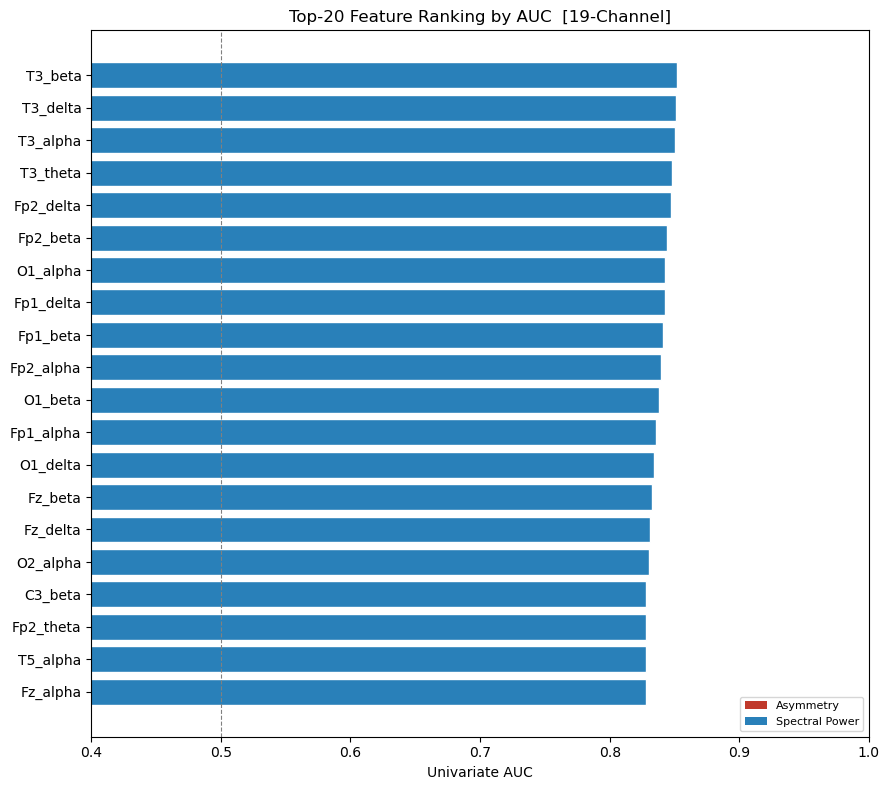

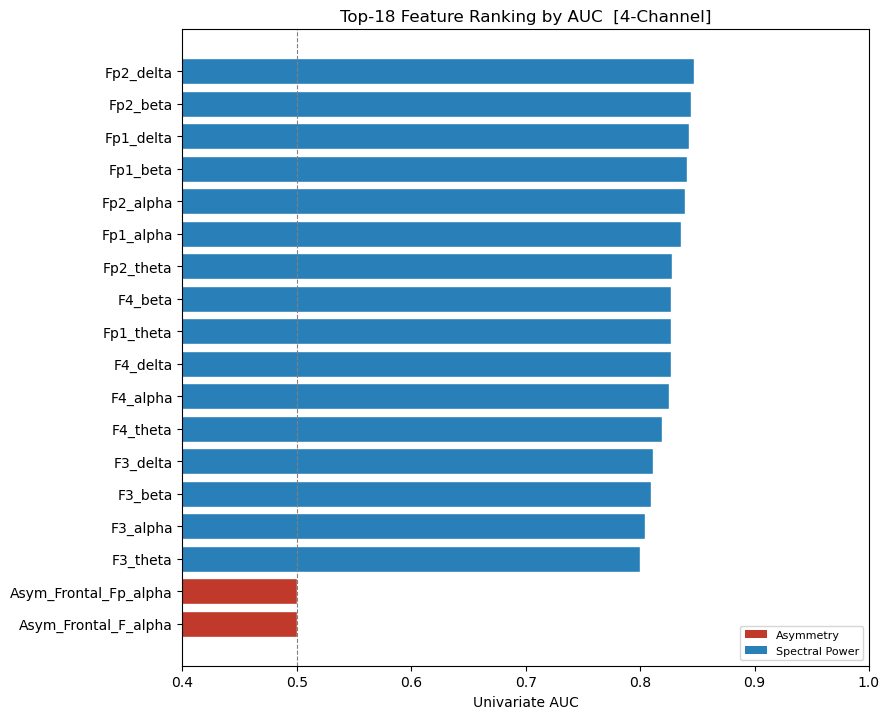

In [14]:
for run in [results_19, results_4]:
    label = run['label']
    top_n = min(20, len(run['all_names']))
    plot_feature_ranking(run['ranked_comb'], top_n=top_n,
                         title=f'[{label}]')

## Cell 15 — Plots: Accuracy vs Feature Subset Size

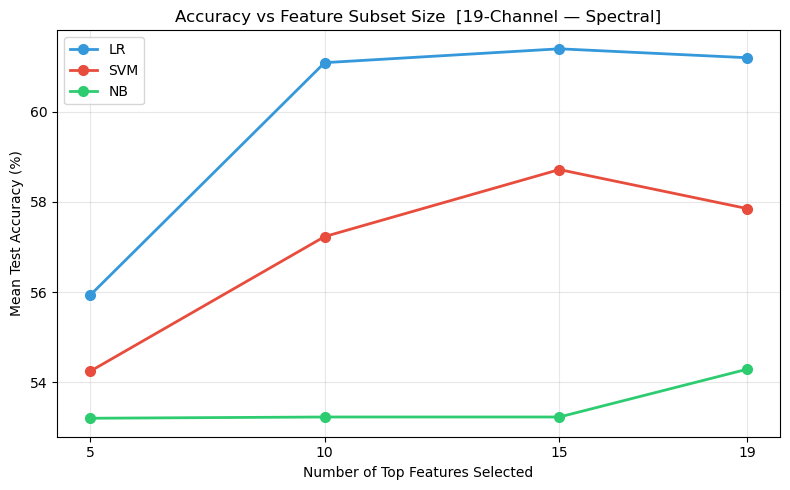

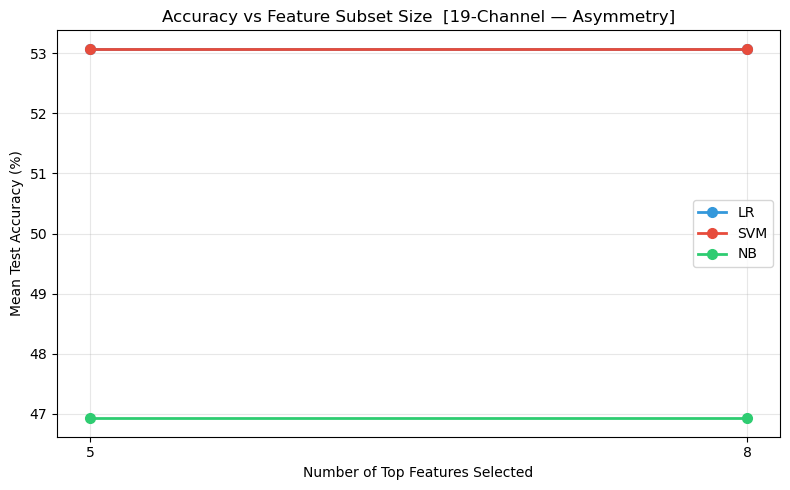

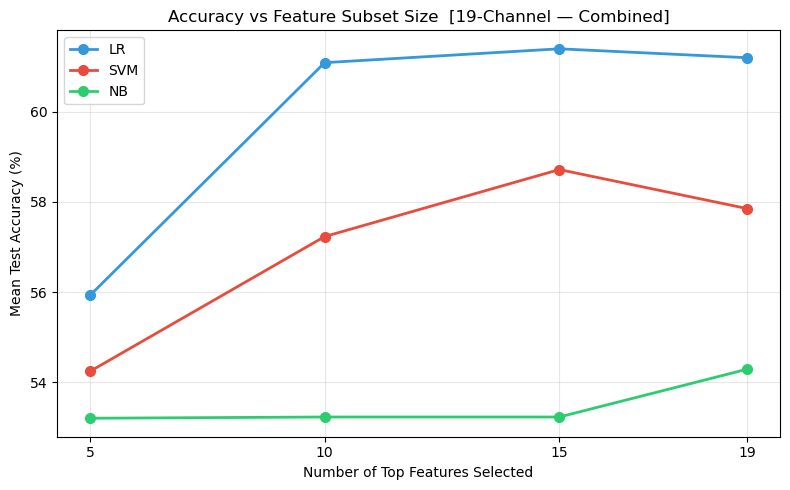

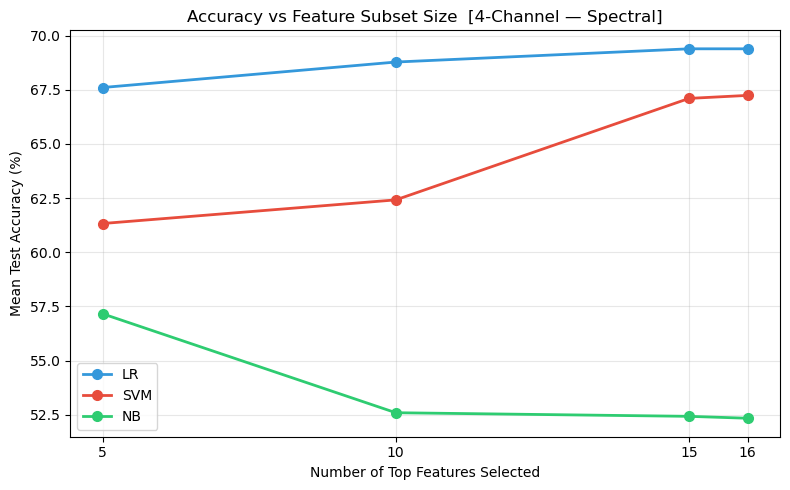

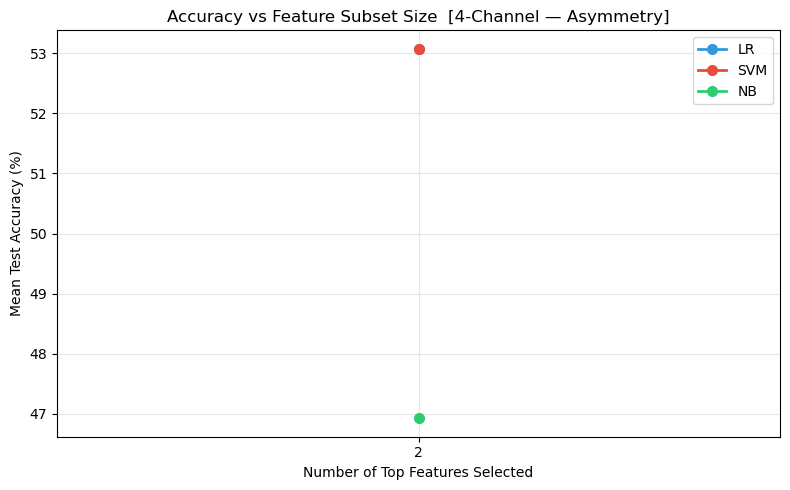

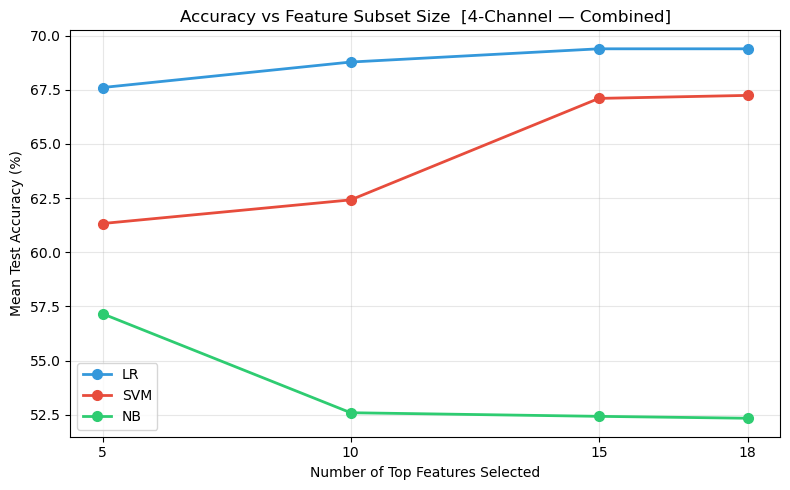

In [15]:
for run in [results_19, results_4]:
    label = run['label']
    for config_name, ss in run['subset_summary'].items():
        subsets = sorted(ss.keys())
        plot_accuracy_by_feature_subset(
            ss, subsets, title_suffix=f'[{label} — {config_name}]'
        )

## Cell 16 — Plots: Confusion Matrices & ROC Curves

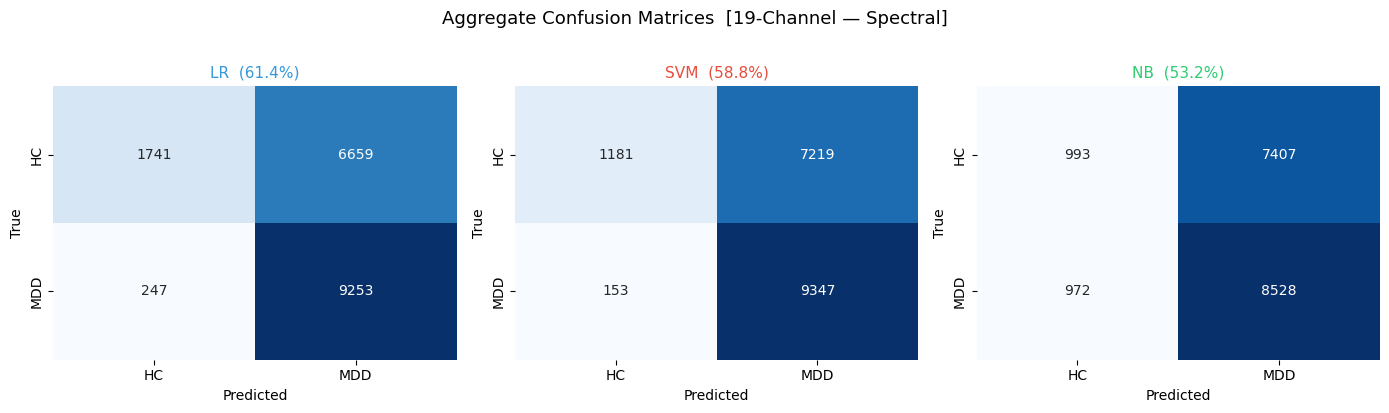

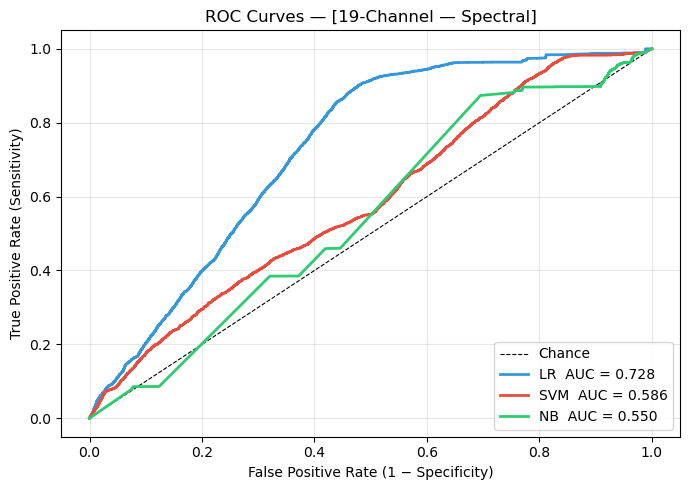

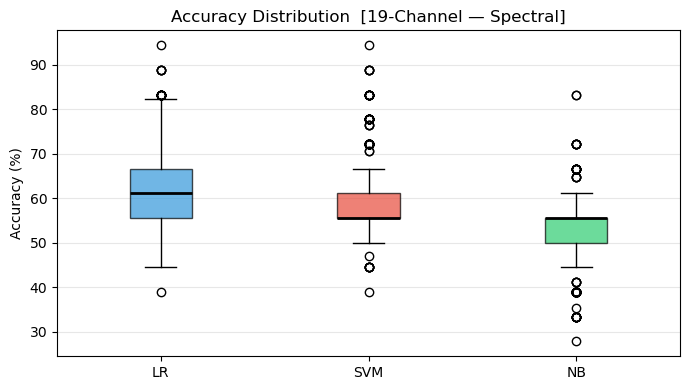

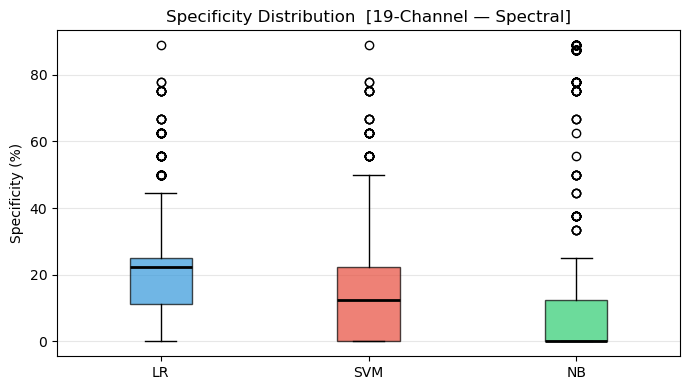

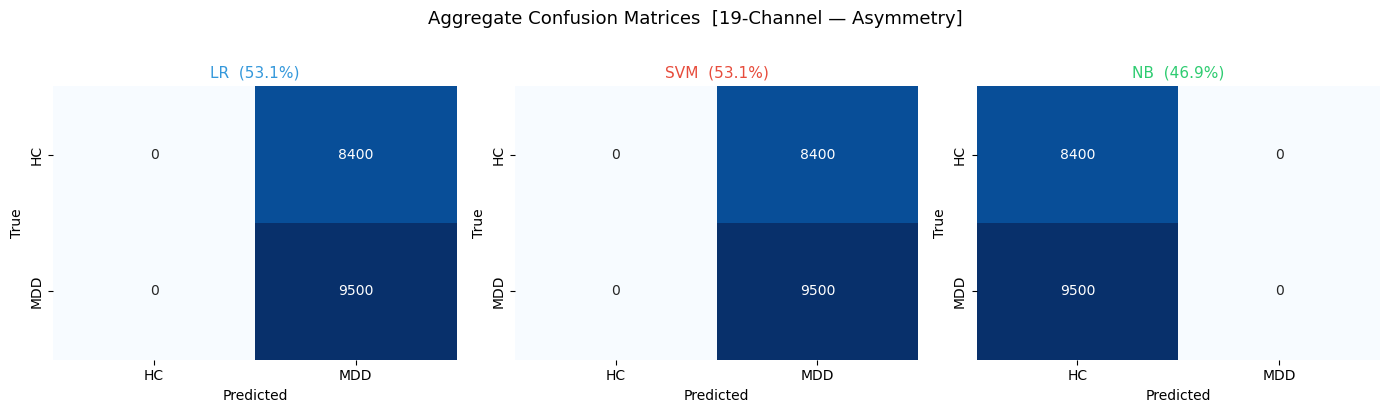

ValueError: Input contains NaN.

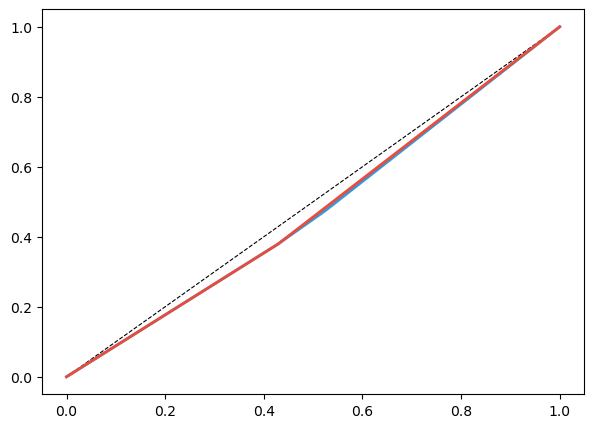

In [16]:
for run in [results_19, results_4]:
    label = run['label']
    for config_name, res in run['full_results'].items():
        tag = f'[{label} — {config_name}]'
        plot_confusion_matrices(res, title_suffix=tag)
        plot_roc_curves(res,          title_suffix=tag)
        plot_metric_boxplots(res, metric='accuracy',    title_suffix=tag)
        plot_metric_boxplots(res, metric='specificity', title_suffix=tag)

## Cell 17 — Final Comparison Table (19-ch vs 4-ch)

In [17]:
rows = []
for run in [results_19, results_4]:
    label = run['label']
    for config_name, res in run['full_results'].items():
        for clf_name, r in res.items():
            rows.append({
                'Config':       label,
                'Features':     config_name,
                'Classifier':   clf_name,
                'Accuracy (%)': round(np.mean(r['accuracy'])  * 100, 2),
                'Sensitivity':  round(np.mean(r['sensitivity'])* 100, 2),
                'Specificity':  round(np.mean(r['specificity'])* 100, 2),
                'AUC':          round(np.nanmean(r['auc']), 4),
            })

df_final = pd.DataFrame(rows).sort_values(
    ['Config', 'Features', 'Accuracy (%)'], ascending=[True, True, False]
).reset_index(drop=True)

print("\n" + "═"*80)
print("  FINAL COMPARISON TABLE")
print("═"*80)
print(df_final.to_string(index=False))

# Optional: save to CSV
df_final.to_csv('EEG_MDD_results_summary.csv', index=False)
print("\n✅ Results saved to EEG_MDD_results_summary.csv")


════════════════════════════════════════════════════════════════════════════════
  FINAL COMPARISON TABLE
════════════════════════════════════════════════════════════════════════════════
    Config  Features Classifier  Accuracy (%)  Sensitivity  Specificity    AUC
19-Channel Asymmetry         LR         53.07       100.00         0.00 0.5000
19-Channel Asymmetry        SVM         53.07       100.00         0.00 0.5000
19-Channel Asymmetry         NB         46.93         0.00       100.00    NaN
19-Channel  Combined         LR         61.41        97.40        20.73 0.8188
19-Channel  Combined        SVM         58.81        98.39        14.04 0.8193
19-Channel  Combined         NB         53.19        89.73        11.77 0.6075
19-Channel  Spectral         LR         61.41        97.40        20.73 0.8188
19-Channel  Spectral        SVM         58.81        98.39        14.04 0.8193
19-Channel  Spectral         NB         53.19        89.73        11.77 0.6075
 4-Channel Asymmetry  

## Cell 18 — Topographic Alpha Asymmetry Visualisation

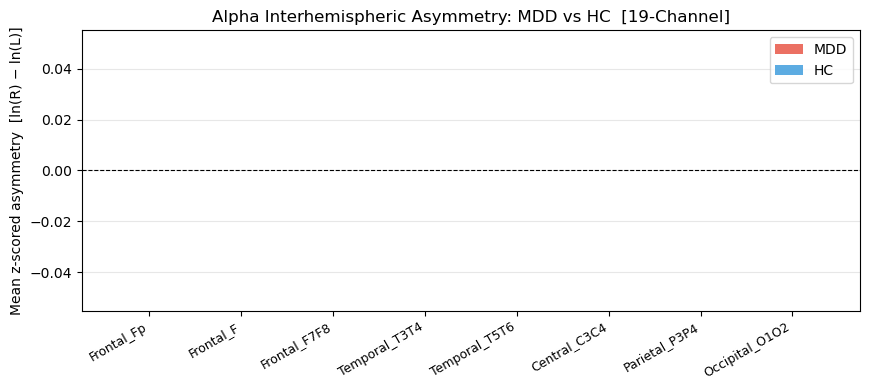

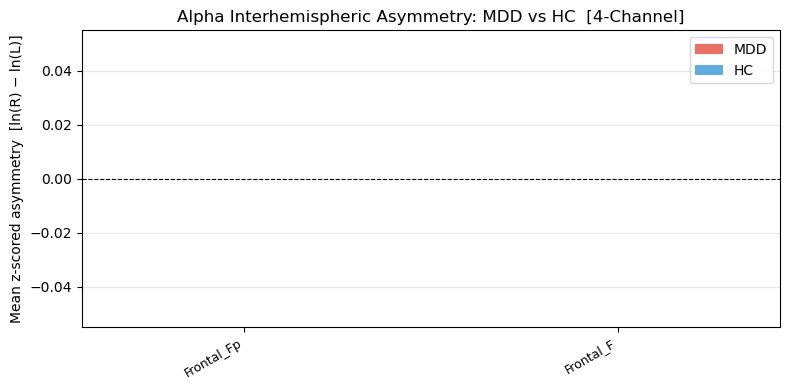

In [18]:
def plot_asymmetry_group_comparison(
    X_asym_z: np.ndarray,
    asym_names: list,
    y: np.ndarray,
    title: str = ""
):
    """
    Bar chart: mean alpha asymmetry per pair for MDD vs HC.
    Helps visualise the frontal alpha asymmetry biomarker.
    """
    n_pairs = len(asym_names)
    if n_pairs == 0:
        print("  No asymmetry features to plot.")
        return

    mdd_means = X_asym_z[y == 1].mean(axis=0)
    hc_means  = X_asym_z[y == 0].mean(axis=0)
    x_pos     = np.arange(n_pairs)
    width     = 0.35

    fig, ax = plt.subplots(figsize=(max(8, n_pairs * 1.1), 4))
    ax.bar(x_pos - width/2, mdd_means, width, label='MDD', color='#e74c3c', alpha=0.8)
    ax.bar(x_pos + width/2, hc_means,  width, label='HC',  color='#3498db', alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([n.replace('Asym_','').replace('_alpha','') for n in asym_names],
                       rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Mean z-scored asymmetry  [ln(R) − ln(L)]')
    ax.set_title(f'Alpha Interhemispheric Asymmetry: MDD vs HC  {title}')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


for run in [results_19, results_4]:
    plot_asymmetry_group_comparison(
        run['X_asym_z'], run['asym_names'], run['y'],
        title=f"[{run['label']}]"
    )

---
## Pipeline Summary

| Step | Description | Key parameter |
|------|-------------|---------------|
| 1 | Load EDF files (`MDD*.edf`, `H*.edf`) | `EEG/` directory |
| 2 | Bandpass 0.5–40 Hz, notch 50 Hz, amplitude rejection | 120 s clean epochs |
| 3 | Welch spectral power (δ θ α β) + alpha asymmetry ln(R)−ln(L) | nperseg=256 |
| 4 | Column-wise concat → z-score normalise | per feature |
| 5 | AUC ranking → top {5,10,15,19} subsets | iterative |
| 6 | LR / SVM(linear) / Naïve Bayes | 100 × 10-fold MC CV |

**Two configurations run in parallel:** `CHANNELS_19` (full cap) and `CHANNELS_4` (frontal subset).